In [8]:
# Jaxlib
import jax
from jax import lax
from jax.experimental import checkify
from jax import random as jrnd
from jax import numpy as jnp
from jax.tree_util import Partial
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt
from collections.abc import Callable

# Mine
from gm_utils import *

In [ ]:
# ERF with median/std + faults + sites/paths
class ERF:
    def __init__(self, medians, stds)

# gm_scenario that takes a Mw + fault + site/path

# hazard calc 
    # Inputs: gmm, faults, sites/paths, medians/stds
    # Returns: hazard curves for all IMTs/vs30s

{'name': 'Deterministic Response Spectra', 'date': '2025-09-26T08:39:05Z', 'status': 'success', 'url': '/spectra', 'request': {'gmms': ['IDRISS_14'], 'input': {'Mw': 7.0, 'rJB': 2.0, 'rRup': 2.0, 'rX': 2.0, 'dip': 85.0, 'width': 2.0, 'zTor': 0.5, 'zHyp': 7.5, 'rake': 40.0, 'vs30': 760.0, 'z1p0': 1.3, 'z2p5': 1.7, 'zSed': None}}, 'response': {'means': {'label': 'Means', 'xLabel': 'Period (s)', 'yLabel': 'Median ground motion (g)', 'data': [{'id': 'IDRISS_14', 'label': 'Idriss (2014)', 'data': {'pga': 0.6001, 'pgv': None, 'sa': {'xs': [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0], 'ys': [0.6001, 0.61653, 0.67661, 0.69796, 0.90077, 1.0609, 1.1492, 1.129, 1.0159, 0.88086, 0.71571, 0.61954, 0.35464, 0.26463, 0.16231, 0.1165, 0.095574, 0.066624, 0.057141, 0.033239, 0.018743]}}, 'tree': [{'id': 'epi-lo', 'values': {'pga': 0.39055, 'pgv': None, 'sa': [0.39055, 0.40123, 0.44034, 0.45423, 0.58622, 0.69041, 0.74787, 0.73472, 0.

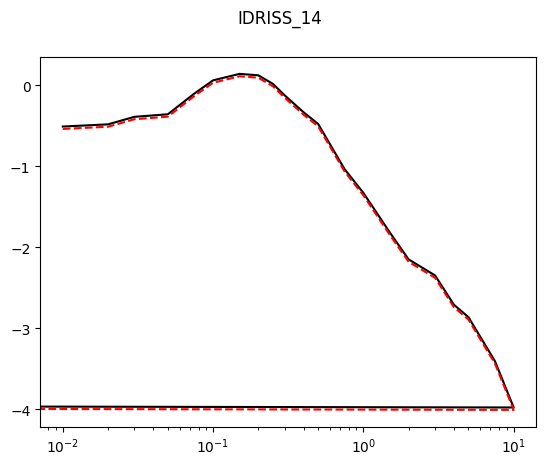

{'name': 'Deterministic Response Spectra', 'date': '2025-09-26T08:39:05Z', 'status': 'success', 'url': '/spectra', 'request': {'gmms': ['IDRISS_14'], 'input': {'Mw': 7.0, 'rJB': 2.0, 'rRup': 2.0, 'rX': 2.0, 'dip': 85.0, 'width': 2.0, 'zTor': 0.5, 'zHyp': 7.5, 'rake': 40.0, 'vs30': 760.0, 'z1p0': 1.3, 'z2p5': 1.7, 'zSed': None}}, 'response': {'means': {'label': 'Means', 'xLabel': 'Period (s)', 'yLabel': 'Median ground motion (g)', 'data': [{'id': 'IDRISS_14', 'label': 'Idriss (2014)', 'data': {'pga': 0.6001, 'pgv': None, 'sa': {'xs': [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0], 'ys': [0.6001, 0.61653, 0.67661, 0.69796, 0.90077, 1.0609, 1.1492, 1.129, 1.0159, 0.88086, 0.71571, 0.61954, 0.35464, 0.26463, 0.16231, 0.1165, 0.095574, 0.066624, 0.057141, 0.033239, 0.018743]}}, 'tree': [{'id': 'epi-lo', 'values': {'pga': 0.39055, 'pgv': None, 'sa': [0.39055, 0.40123, 0.44034, 0.45423, 0.58622, 0.69041, 0.74787, 0.73472, 0.

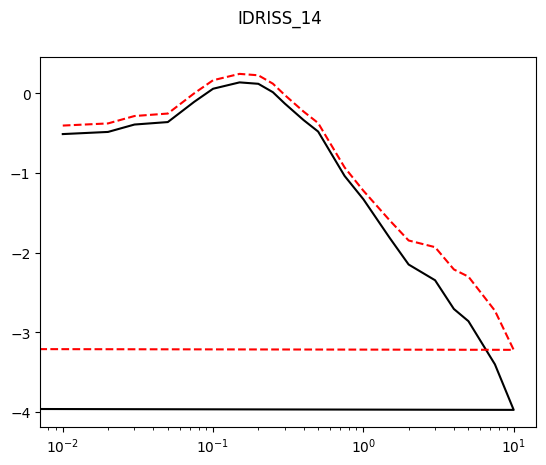

{'name': 'Deterministic Response Spectra', 'date': '2025-09-26T08:39:05Z', 'status': 'success', 'url': '/spectra', 'request': {'gmms': ['IDRISS_14'], 'input': {'Mw': 7.0, 'rJB': 2.0, 'rRup': 2.0, 'rX': 2.0, 'dip': 85.0, 'width': 2.0, 'zTor': 0.5, 'zHyp': 7.5, 'rake': 40.0, 'vs30': 760.0, 'z1p0': 1.3, 'z2p5': 1.7, 'zSed': None}}, 'response': {'means': {'label': 'Means', 'xLabel': 'Period (s)', 'yLabel': 'Median ground motion (g)', 'data': [{'id': 'IDRISS_14', 'label': 'Idriss (2014)', 'data': {'pga': 0.6001, 'pgv': None, 'sa': {'xs': [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0], 'ys': [0.6001, 0.61653, 0.67661, 0.69796, 0.90077, 1.0609, 1.1492, 1.129, 1.0159, 0.88086, 0.71571, 0.61954, 0.35464, 0.26463, 0.16231, 0.1165, 0.095574, 0.066624, 0.057141, 0.033239, 0.018743]}}, 'tree': [{'id': 'epi-lo', 'values': {'pga': 0.39055, 'pgv': None, 'sa': [0.39055, 0.40123, 0.44034, 0.45423, 0.58622, 0.69041, 0.74787, 0.73472, 0.

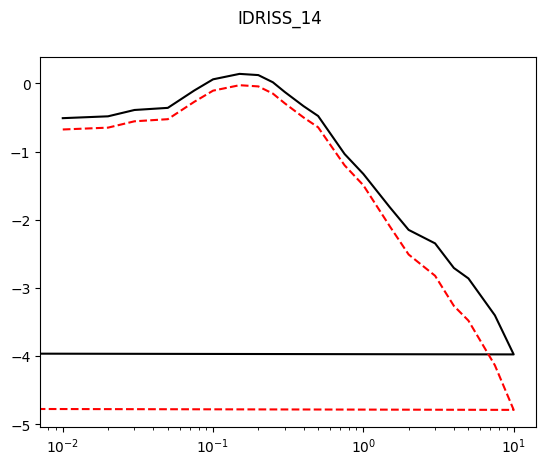

In [ ]:
import requests
from ASK14 import f_ASK14
from BSSA14 import f_BSSA14 
from CY14 import f_CY14 
from CB14 import f_CB14
from Idriss14 import f_Idriss14
from epistemic_AAY14 import f_epistemic_AAY14

def test_model(scn:gm_scenario, name, model):
    my_T, my_lnSA, my_sigma = model(scn)

    # API
    url_base = 'https://earthquake.usgs.gov/ws/nshmp/gmm/spectra?'
    url_inputs = (name, scn.Mw, scn.R_jb, scn.R_rup, scn.R_x, scn.dip, scn.width, scn.z_tor, scn.z_hyp, scn.rake, scn.vs30, scn.z1p0, scn.z2p5)
    url_addn = 'gmm=%s&Mw=%s&rJB=%s&rRup=%s&rX=%s&dip=%s&width=%s&z_tor=%s&z_hyp=%s&rake=%s&vs30=%s&z1p0=%s&z2p5=%s'%url_inputs
    json = requests.get(url_base + url_addn).json()
    print(json)
    api_T = json['response']['means']['data'][0]['data']['sa']['xs']
    api_PGA, api_PGV = [json['response']['means']['data'][0]['data'][key] for key in ['pga', 'pgv']]
    if api_PGV is None:
        api_PGV = jnp.nan
    api_SA = json['response']['means']['data'][0]['data']['sa']['ys']
    api_T, api_SA= [jnp.array(_) for _ in [api_T, api_SA]]
    api_T = jnp.append(api_T, jnp.array([-1, -2]))
    api_SA = jnp.append(api_SA, jnp.array([api_PGA, api_PGV]))
    api_lnSA = jnp.log(api_SA)

    plt.plot(api_T, api_lnSA, c = 'k')
    plt.plot(my_T, my_lnSA, c = 'r', ls = '--')
    plt.xscale('log')
    plt.suptitle(name)
    plt.show()



f_Idriss_plus_ep = f_epistemic_AAY14(f_Idriss14, 1.645)
f_Idriss_minus_ep = f_epistemic_AAY14(f_Idriss14, -1.645)
scn = gm_scenario(7., 85., 40., 2., 2., 2., 2., 760, 1.3, 1.7, 0.4, 0.1)